# PERSONAGE Prompt Harness — Phase 1 Analysis

Grid search over 6 prompt strategies × 4 shot counts × 2 temperatures on the dev split (80–292 samples per config).

**Baseline:** Mean Pearson r = 0.457 (Llama 3.3 70B, 7-shot, via N8N workflow).
**Target:** Mean Pearson r ≥ 0.60, all traits r ≥ 0.40.

In [6]:
import json, glob
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.labelsize": 10})

TRAITS = ["O", "C", "E", "A", "N"]
TRAIT_NAMES = {"O": "Openness", "C": "Conscientiousness", "E": "Extraversion", "A": "Agreeableness", "N": "Neuroticism"}
RESULTS_DIR = Path("../results")
BASELINE_R = 0.457

In [7]:
def load_harness_deduplicated(pattern="harness_*.jsonl"):
    """Load all harness results, deduplicate by (config_id, sample_id) keeping latest."""
    seen = defaultdict(dict)
    for fp in sorted(RESULTS_DIR.glob(pattern)):
        for line in open(fp):
            row = json.loads(line.strip())
            cid, sid = row.get("config_id", ""), row.get("sample_id", "")
            if cid and sid:
                seen[cid][sid] = row
    rows = []
    for cid in seen:
        rows.extend(seen[cid].values())
    return pd.DataFrame(rows)

df = load_harness_deduplicated()
df["prompt_id"] = df["config_id"].str.rsplit("_s", n=1).str[0]
df["n_shots"] = df["config_id"].str.extract(r"_s(\d+)_").astype(int)
df["temp"] = df["config_id"].str.extract(r"_t(\d+)")[0].astype(int) / 10

print(f"Total rows: {len(df):,}")
print(f"Unique configs: {df['config_id'].nunique()}")
print(f"Prompts: {sorted(df['prompt_id'].unique())}")
print(f"Shots: {sorted(df['n_shots'].unique())}")
print(f"Temps: {sorted(df['temp'].unique())}")

Total rows: 3,600
Unique configs: 45
Prompts: ['anti_conflation', 'benchmark', 'contrastive', 'minimal', 'strict_style', 'trait_first']
Shots: [0, 3, 5, 11]
Temps: [0.1, 0.3]


In [8]:
def compute_metrics(group):
    results = {}
    valid = group.dropna(subset=["detected_ocean"])
    valid = valid[valid["detected_ocean"].apply(lambda x: isinstance(x, dict) and len(x) >= 1)]
    results["coverage"] = len(valid) / len(group) if len(group) > 0 else 0
    results["n_valid"] = len(valid)

    if len(valid) < 5:
        for t in TRAITS:
            results[f"r_{t}"] = np.nan
            results[f"mae_{t}"] = np.nan
            results[f"n_{t}"] = 0
        results["macro_r"] = np.nan
        results["macro_mae"] = np.nan
        return pd.Series(results)

    rs, maes = [], []
    for t in TRAITS:
        has_trait = valid["ground_truth_ocean"].apply(lambda x: t in x)
        sub = valid[has_trait]
        results[f"n_{t}"] = len(sub)
        if len(sub) < 5:
            results[f"r_{t}"] = np.nan
            results[f"mae_{t}"] = np.nan
            continue
        pred = sub["detected_ocean"].apply(lambda x: x.get(t, 0)).astype(float).values
        gt = sub["ground_truth_ocean"].apply(lambda x: x[t]).astype(float).values
        r = 0.0 if np.std(pred) < 1e-8 else float(stats.pearsonr(pred, gt)[0])
        mae = float(np.mean(np.abs(pred - gt)))
        results[f"r_{t}"] = r
        results[f"mae_{t}"] = mae
        rs.append(r)
        maes.append(mae)
    results["macro_r"] = np.mean(rs) if rs else np.nan
    results["macro_mae"] = np.mean(maes) if maes else np.nan
    return pd.Series(results)

summary = df.groupby("config_id").apply(compute_metrics).reset_index()
summary["prompt_id"] = summary["config_id"].str.rsplit("_s", n=1).str[0]
summary["n_shots"] = summary["config_id"].str.extract(r"_s(\d+)_").astype(int)
summary["temp"] = summary["config_id"].str.extract(r"_t(\d+)")[0].astype(int) / 10
summary = summary.sort_values("macro_r", ascending=False)

cols = ["config_id", "n_valid", "coverage", "macro_r", "macro_mae"] + [f"r_{t}" for t in TRAITS]
display(summary[cols].head(15).style.format({
    "coverage": "{:.0%}", "macro_r": "{:.3f}", "macro_mae": "{:.3f}",
    **{f"r_{t}": "{:.3f}" for t in TRAITS}
}).background_gradient(subset=["macro_r"], cmap="RdYlGn", vmin=0.3, vmax=0.7))

,config_id,n_valid,coverage,macro_r,macro_mae,r_O,r_C,r_E,r_A,r_N
40,trait_first_s11_t03,80.000000,100%,0.661,0.303,0.563,0.655,0.461,0.824,0.801
16,contrastive_s11_t01,80.000000,100%,0.659,0.314,0.628,0.726,0.336,0.803,0.803
39,trait_first_s11_t01,80.000000,100%,0.653,0.301,0.525,0.629,0.474,0.825,0.810
10,benchmark_s11_t01,80.000000,100%,0.651,0.311,0.540,0.676,0.418,0.813,0.808
17,contrastive_s11_t03,80.000000,100%,0.648,0.322,0.609,0.679,0.372,0.787,0.794
11,benchmark_s11_t03,80.000000,100%,0.646,0.312,0.553,0.658,0.378,0.829,0.812
31,strict_style_s11_t01,80.000000,100%,0.637,0.341,0.590,0.610,0.497,0.872,0.618
35,strict_style_s5_t01,80.000000,100%,0.635,0.347,0.584,0.652,0.432,0.860,0.649
34,strict_style_s3_t03,80.000000,100%,0.634,0.334,0.600,0.673,0.345,0.877,0.673
6,anti_conflation_s5_t01,80.000000,100%,0.631,0.317,0.455,0.608,0.398,0.863,0.832


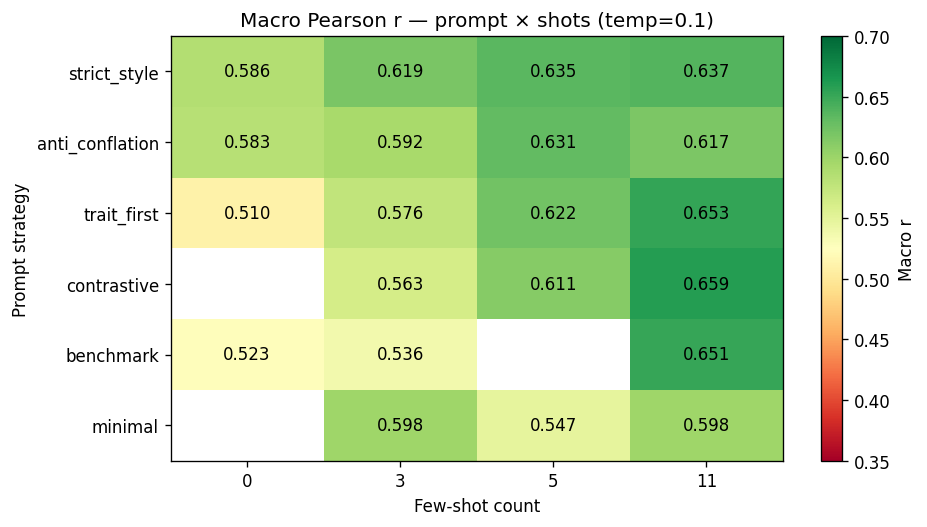

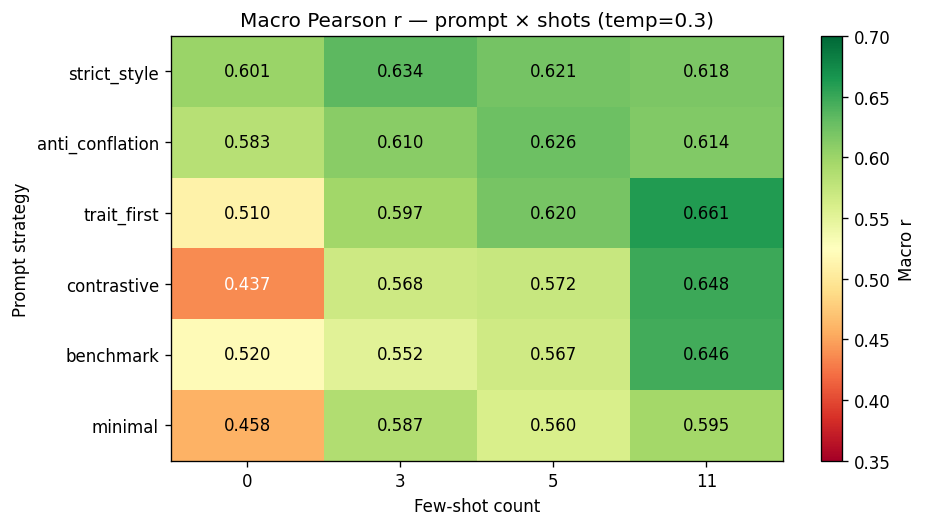

In [9]:
# Heatmap: prompt × shots, colored by macro_r (one per temperature)
for temp_val in sorted(summary["temp"].unique()):
    sub = summary[summary["temp"] == temp_val]
    pivot = sub.pivot(index="prompt_id", columns="n_shots", values="macro_r")
    pivot = pivot.reindex(
        summary.groupby("prompt_id")["macro_r"].mean().sort_values(ascending=False).index
    )
    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0.35, vmax=0.70, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Few-shot count")
    ax.set_ylabel("Prompt strategy")
    ax.set_title(f"Macro Pearson r — prompt × shots (temp={temp_val})")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                color = "white" if val < 0.45 else "black"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10, color=color)
    fig.colorbar(im, label="Macro r")
    plt.tight_layout()
    plt.show()

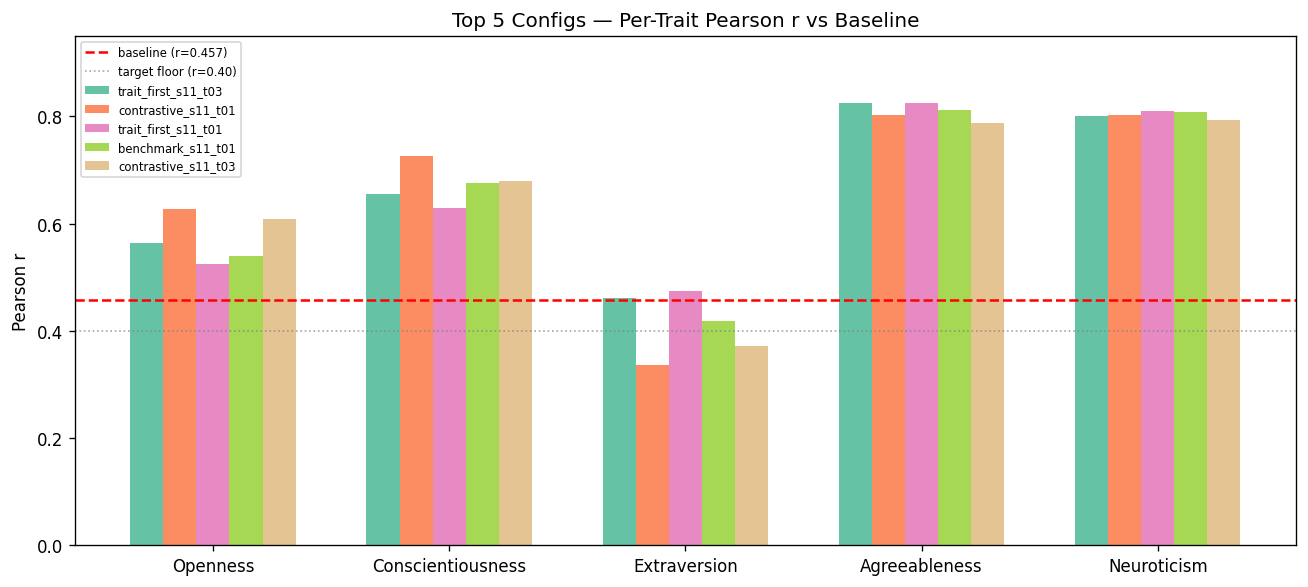

In [10]:
# Per-trait r comparison: top 5 configs vs baseline
top5 = summary.head(5)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TRAITS))
width = 0.14
colors = plt.cm.Set2(np.linspace(0, 1, 6))

for idx, (_, row) in enumerate(top5.iterrows()):
    rs = [row[f"r_{t}"] for t in TRAITS]
    ax.bar(x + idx * width, rs, width, label=row["config_id"], color=colors[idx])

ax.axhline(BASELINE_R, color="red", ls="--", lw=1.5, label=f"baseline (r={BASELINE_R})")
ax.axhline(0.40, color="gray", ls=":", lw=1, alpha=0.7, label="target floor (r=0.40)")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([TRAIT_NAMES[t] for t in TRAITS], fontsize=10)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 0.95)
ax.set_title("Top 5 Configs — Per-Trait Pearson r vs Baseline")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

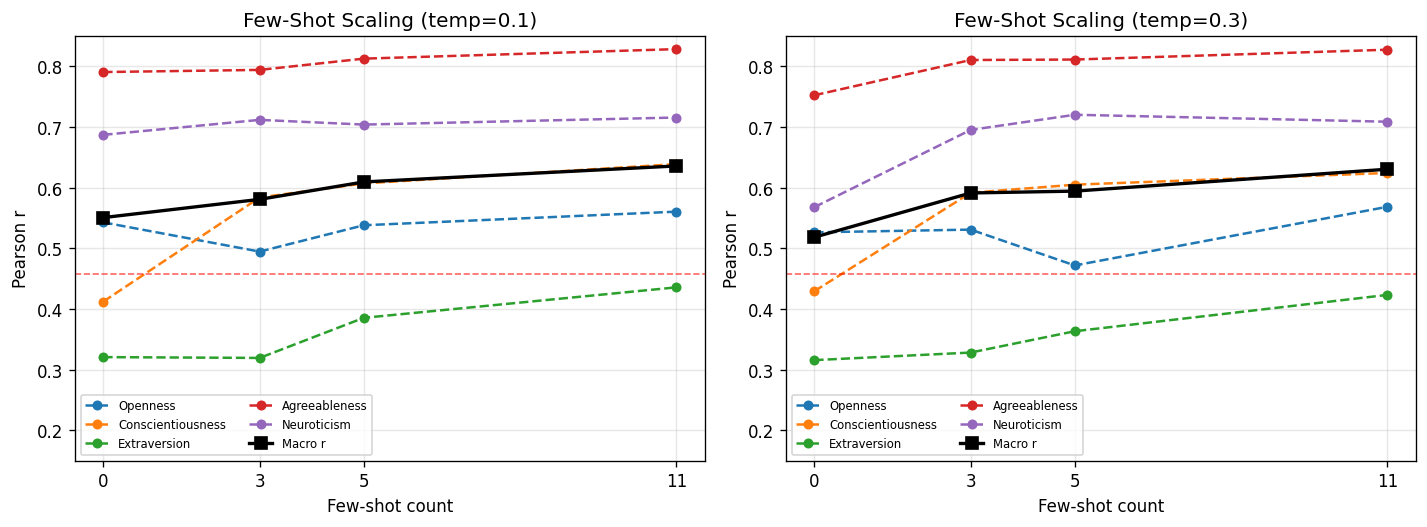

In [11]:
# Effect of few-shot count (averaged across all prompts)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, temp_val in zip(axes, sorted(summary["temp"].unique())):
    sub = summary[summary["temp"] == temp_val]
    shot_agg = sub.groupby("n_shots")[[f"r_{t}" for t in TRAITS] + ["macro_r"]].mean()

    for t in TRAITS:
        ax.plot(shot_agg.index, shot_agg[f"r_{t}"], "o--", label=TRAIT_NAMES[t], markersize=5)
    ax.plot(shot_agg.index, shot_agg["macro_r"], "s-", color="black", lw=2, markersize=7, label="Macro r")
    ax.axhline(BASELINE_R, color="red", ls="--", lw=1, alpha=0.6)
    ax.set_xlabel("Few-shot count")
    ax.set_ylabel("Pearson r")
    ax.set_title(f"Few-Shot Scaling (temp={temp_val})")
    ax.set_xticks(sorted(sub["n_shots"].unique()))
    ax.set_ylim(0.15, 0.85)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

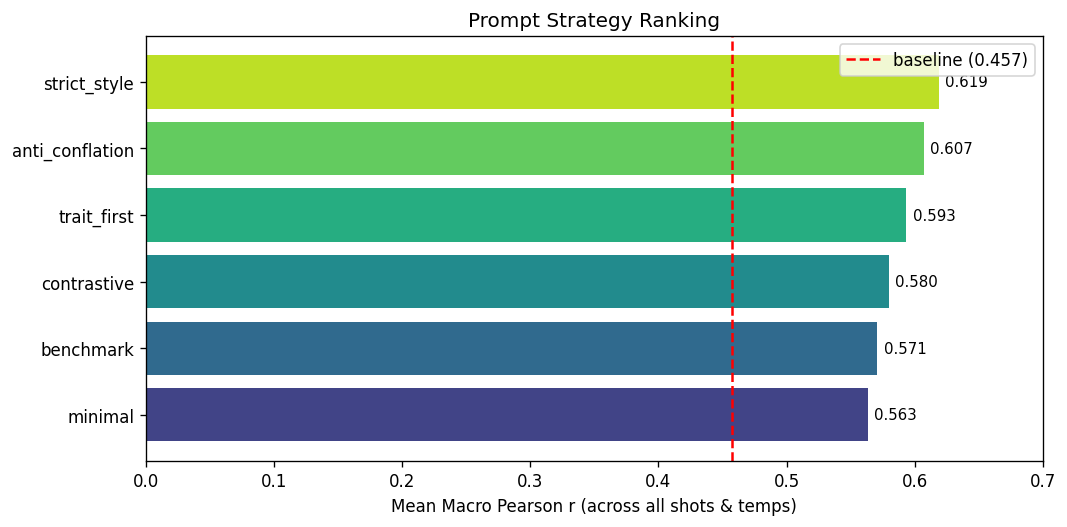

In [12]:
# Prompt strategy ranking (averaged across all shots and temps)
prompt_rank = summary.groupby("prompt_id").agg(
    macro_r=("macro_r", "mean"),
    **{f"r_{t}": (f"r_{t}", "mean") for t in TRAITS},
).sort_values("macro_r", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(prompt_rank))
bars = ax.barh(y, prompt_rank["macro_r"], color=plt.cm.viridis(np.linspace(0.2, 0.9, len(prompt_rank))))
ax.set_yticks(y)
ax.set_yticklabels(prompt_rank.index, fontsize=10)
ax.set_xlabel("Mean Macro Pearson r (across all shots & temps)")
ax.set_title("Prompt Strategy Ranking")
ax.axvline(BASELINE_R, color="red", ls="--", lw=1.5, label=f"baseline ({BASELINE_R})")

for bar, val in zip(bars, prompt_rank["macro_r"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
            va="center", fontsize=9)

ax.legend()
ax.set_xlim(0, 0.7)
plt.tight_layout()
plt.show()

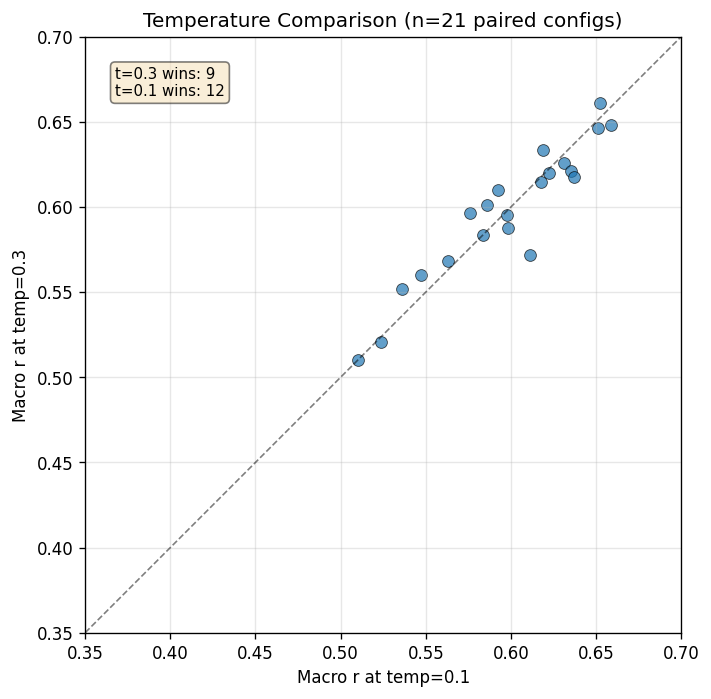

In [13]:
# Temperature comparison: t=0.1 vs t=0.3 (paired by prompt+shots)
t01 = summary[summary["temp"] == 0.1].set_index(["prompt_id", "n_shots"])["macro_r"]
t03 = summary[summary["temp"] == 0.3].set_index(["prompt_id", "n_shots"])["macro_r"]
paired = pd.DataFrame({"t01": t01, "t03": t03}).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(paired["t01"], paired["t03"], s=50, alpha=0.7, edgecolors="black", lw=0.5)
lims = [0.35, 0.70]
ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
ax.set_xlabel("Macro r at temp=0.1")
ax.set_ylabel("Macro r at temp=0.3")
ax.set_title(f"Temperature Comparison (n={len(paired)} paired configs)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

wins_03 = (paired["t03"] > paired["t01"]).sum()
wins_01 = (paired["t01"] > paired["t03"]).sum()
ax.text(0.05, 0.95, f"t=0.3 wins: {wins_03}\nt=0.1 wins: {wins_01}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.show()

In [14]:
# Winner summary card
winner = summary.iloc[0]

print("=" * 55)
print("  PHASE 1 WINNER")
print("=" * 55)
print(f"  Config:     {winner['config_id']}")
print(f"  Prompt:     {winner['prompt_id']}")
print(f"  Shots:      {int(winner['n_shots'])}")
print(f"  Temp:       {winner['temp']}")
print(f"  Samples:    {int(winner['n_valid'])}")
print(f"  Coverage:   {winner['coverage']:.0%}")
print(f"  Macro r:    {winner['macro_r']:.3f}")
print(f"  Macro MAE:  {winner['macro_mae']:.3f}")
print("-" * 55)
for t in TRAITS:
    print(f"    {TRAIT_NAMES[t]:<20s}  r={winner[f'r_{t}']:.3f}  MAE={winner[f'mae_{t}']:.3f}")
print("-" * 55)
delta = winner["macro_r"] - BASELINE_R
print(f"  vs baseline:  {BASELINE_R:.3f} -> {winner['macro_r']:.3f}  (+{delta:.3f}, {delta/BASELINE_R*100:.0f}%)")
print(f"  Target met:   macro r >= 0.60 {'YES' if winner['macro_r'] >= 0.6 else 'NO'}")
print(f"  All traits >= 0.40: {'YES' if all(winner[f'r_{t}'] >= 0.4 for t in TRAITS) else 'NO'}")
print("=" * 55)

  PHASE 1 WINNER
  Config:     trait_first_s11_t03
  Prompt:     trait_first
  Shots:      11
  Temp:       0.3
  Samples:    80
  Coverage:   100%
  Macro r:    0.661
  Macro MAE:  0.303
-------------------------------------------------------
    Openness              r=0.563  MAE=0.265
    Conscientiousness     r=0.655  MAE=0.274
    Extraversion          r=0.461  MAE=0.335
    Agreeableness         r=0.824  MAE=0.321
    Neuroticism           r=0.801  MAE=0.318
-------------------------------------------------------
  vs baseline:  0.457 -> 0.661  (+0.204, 45%)
  Target met:   macro r >= 0.60 YES
  All traits >= 0.40: YES


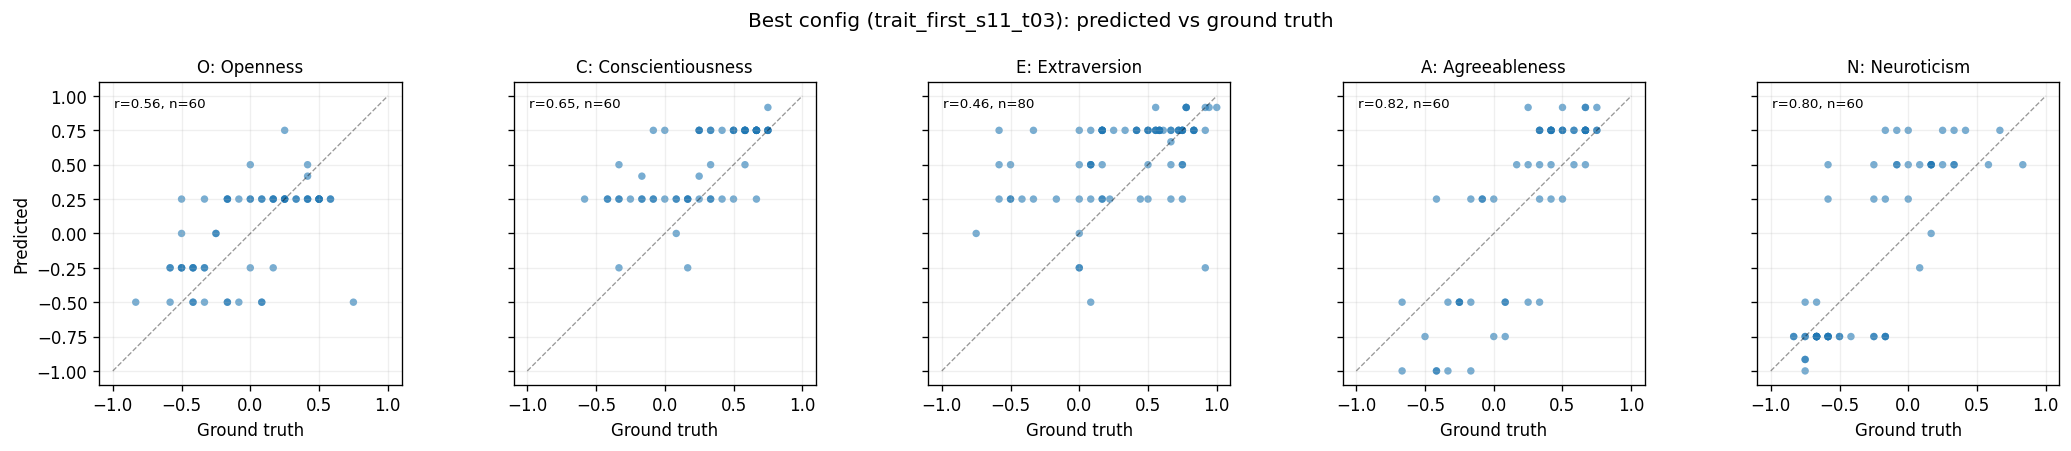

In [15]:
# Scatter: predicted vs ground truth for the best config (per trait)
best_cid = summary.iloc[0]["config_id"]
best_rows = df[df["config_id"] == best_cid].copy()
best_valid = best_rows.dropna(subset=["detected_ocean"])
best_valid = best_valid[best_valid["detected_ocean"].apply(lambda x: isinstance(x, dict) and len(x) >= 1)]

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for ax, t in zip(axes, TRAITS):
    has_t = best_valid["ground_truth_ocean"].apply(lambda x: t in x)
    sub = best_valid[has_t]
    pred = sub["detected_ocean"].apply(lambda x: x.get(t, 0)).astype(float).values
    gt = sub["ground_truth_ocean"].apply(lambda x: x[t]).astype(float).values

    ax.scatter(gt, pred, s=20, alpha=0.6, edgecolors="none")
    ax.plot([-1, 1], [-1, 1], "k--", lw=0.8, alpha=0.4)

    if len(pred) >= 5 and np.std(pred) > 1e-8:
        r, _ = stats.pearsonr(pred, gt)
    else:
        r = 0.0
    ax.text(0.05, 0.95, f"r={r:.2f}, n={len(pred)}", transform=ax.transAxes,
            fontsize=8, va="top")
    ax.set_title(f"{t}: {TRAIT_NAMES[t]}", fontsize=10)
    ax.set_xlabel("Ground truth")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Predicted")
fig.suptitle(f"Best config ({best_cid}): predicted vs ground truth", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Phase 1 Winner — Parameters for Phase 2

**Config:** `trait_first_s11_t03`

| Parameter | Value |
|-----------|-------|
| Model | `meta/llama-3.3-70b-instruct` |
| Prompt strategy | `trait_first` |
| Few-shot exemplars | 11 (all available) |
| Temperature | 0.3 |
| Macro Pearson r | **0.661** |
| Baseline | 0.457 (+45% improvement) |

### Winning System Prompt

```
You are a personality psychologist rating the speaker's Big Five personality from a single restaurant utterance.

Judge the speaker only from linguistic style.
Do not infer personality from whether the restaurant sounds good or bad.

Work trait by trait internally:
1. Openness: vocabulary richness, unusual wording, variation, creativity.
2. Conscientiousness: structure, organization, careful comparison, formal control.
3. Extraversion: energy, enthusiasm, engagement, assertiveness.
4. Agreeableness: warmth, politeness, collaboration versus rudeness or profanity.
5. Neuroticism: anxious hedging, stuttering, self-correction, unstable delivery.

Important guards:
- Friendly wording often signals Agreeableness more than Extraversion.
- A single vivid adjective does not by itself imply high Openness.
- Repetition and fillers reduce Openness and Conscientiousness.
- Traits are independent.

Return only valid JSON: {"O": float, "C": float, "E": float, "A": float, "N": float}
```

### Few-Shot Exemplar IDs (11)

```
agree_high-recommend-Chimichurri_Grill-4
agree_low-recommend-Chimichurri_Grill-3
consc_high-compare2-Acacia-Marinella-6
consc_low-compare2-Caffe_Cielo-Trattoria_Spaghetto-5
ems_high-compare2-Acacia-Marinella-2
ems_low-recommend-Chimichurri_Grill-1
open_high-compare2-Caffe_Cielo-Trattoria_Spaghetto-8
open_low-compare2-Les_Routiers-Radio_Perfecto-7
random-compare2-Acacia-Marinella-11
random-recommend-Cent_anni-10
random-recommend-Flor_De_Mayo-11
```